In [1]:
import pandas as pd

# Load the datasets
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

# Check shape
print("Matches dataset:", matches.shape)
print("Deliveries dataset:", deliveries.shape)

Matches dataset: (1095, 20)
Deliveries dataset: (260920, 17)


In [2]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [3]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
# See all columns in both datasets
print("MATCHES columns:")
print(matches.columns.tolist())

print("\nDELIVERIES columns:")
print(deliveries.columns.tolist())

MATCHES columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

DELIVERIES columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [5]:
# See all unique batsmen
batsmen = deliveries['batter'].unique()
print(f"Total unique batsmen: {len(batsmen)}")
print("\nFirst 20 batsmen:")
print(batsmen[:20])

Total unique batsmen: 673

First 20 batsmen:
['SC Ganguly' 'BB McCullum' 'RT Ponting' 'DJ Hussey' 'Mohammad Hafeez'
 'R Dravid' 'W Jaffer' 'V Kohli' 'JH Kallis' 'CL White' 'MV Boucher'
 'B Akhil' 'AA Noffke' 'P Kumar' 'Z Khan' 'SB Joshi' 'PA Patel'
 'ML Hayden' 'MEK Hussey' 'MS Dhoni']


In [6]:
# Let's pick Mahi for now
player = "MS Dhoni"

# Filter all deliveries faced by this player
player_data = deliveries[deliveries['batter'] == player]

print(f"Total balls faced by {player}: {len(player_data)}")
print(f"Total runs scored: {player_data['batsman_runs'].sum()}")

Total balls faced by MS Dhoni: 3947
Total runs scored: 5243


In [7]:
# Dhoni's basic batting stats
total_balls = len(player_data)
total_runs = player_data['batsman_runs'].sum()
dismissals = player_data['is_wicket'].sum()
dot_balls = len(player_data[player_data['batsman_runs'] == 0])

strike_rate = (total_runs / total_balls) * 100
dot_percentage = (dot_balls / total_balls) * 100

print(f"Player: {player}")
print(f"Total Balls Faced : {total_balls}")
print(f"Total Runs Scored : {total_runs}")
print(f"Total Dismissals  : {dismissals}")
print(f"Strike Rate       : {strike_rate:.2f}")
print(f"Dot Ball %        : {dot_percentage:.2f}%")

Player: MS Dhoni
Total Balls Faced : 3947
Total Runs Scored : 5243
Total Dismissals  : 149
Strike Rate       : 132.84
Dot Ball %        : 36.05%


In [8]:
# Define phases based on over number
# Overs 0-5 = Powerplay, 6-14 = Middle, 15-19 = Death

def get_phase(over):
    if over <= 5:
        return 'Powerplay (0-5)'
    elif over <= 14:
        return 'Middle (6-14)'
    else:
        return 'Death (15-19)'

# Add phase column to player data
player_data = player_data.copy()
player_data['phase'] = player_data['over'].apply(get_phase)

# Calculate stats per phase
phase_stats = player_data.groupby('phase').agg(
    balls=('batsman_runs', 'count'),
    runs=('batsman_runs', 'sum'),
    dismissals=('is_wicket', 'sum')
).reset_index()

# Add strike rate per phase
phase_stats['strike_rate'] = (phase_stats['runs'] / phase_stats['balls'] * 100).round(2)

print(phase_stats)

             phase  balls  runs  dismissals  strike_rate
0    Death (15-19)   1958  3292         104       168.13
1    Middle (6-14)   1911  1892          43        99.01
2  Powerplay (0-5)     78    59           2        75.64


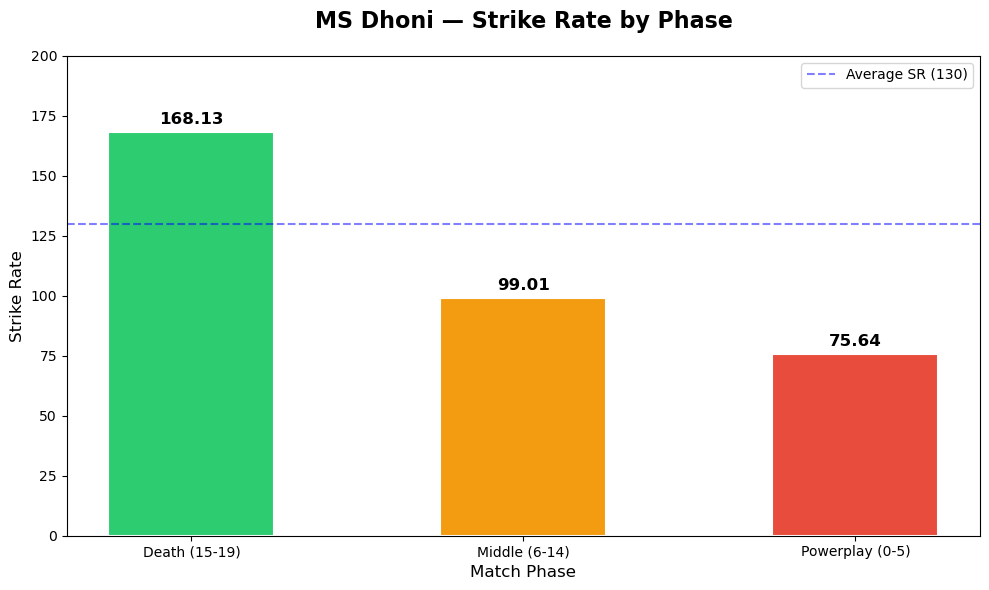

Chart saved!


In [9]:
import matplotlib.pyplot as plt

# Data for chart
phases = phase_stats['phase']
strike_rates = phase_stats['strike_rate']
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # green, orange, red

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(phases, strike_rates, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Add value labels on top of each bar
for bar, val in zip(bars, strike_rates):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 2, 
             f'{val}', 
             ha='center', va='bottom', 
             fontsize=12, fontweight='bold')

# Styling
plt.title(f'{player} — Strike Rate by Phase', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Match Phase', fontsize=12)
plt.ylabel('Strike Rate', fontsize=12)
plt.ylim(0, 200)
plt.axhline(y=130, color='blue', linestyle='--', alpha=0.5, label='Average SR (130)')
plt.legend()
plt.tight_layout()
plt.savefig('dhoni_phase_strike_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [10]:
# so this is day 2 of our project , today we'll find:

# Which bowler type troubles him (pace vs spin)
# Which over range he struggles in
# Which balls he gets out most on

In [11]:
# Check dismissal types against Dhoni
dismissals_only = player_data[player_data['is_wicket'] == 1]

print(f"Total dismissals: {len(dismissals_only)}")
print(f"\nHow he gets out most:")
print(dismissals_only['dismissal_kind'].value_counts())

Total dismissals: 149

How he gets out most:
dismissal_kind
caught               92
run out              25
bowled               20
lbw                   5
caught and bowled     4
stumped               3
Name: count, dtype: int64


In [12]:
# Which bowlers dismissed Dhoni most
top_bowlers = dismissals_only['bowler'].value_counts().head(10)

print("Top 10 bowlers who dismissed Dhoni:")
print(top_bowlers)

Top 10 bowlers who dismissed Dhoni:
bowler
PP Ojha       7
Z Khan        7
CV Varun      4
JJ Bumrah     4
KA Pollard    3
A Nehra       3
YS Chahal     3
TA Boult      3
SR Watson     3
HV Patel      3
Name: count, dtype: int64


In [13]:
# Separate pace and spin bowlers manually
# We'll classify based on known bowlers in the dataset

# First let's see all bowlers who dismissed Dhoni
all_dismissal_bowlers = dismissals_only['bowler'].value_counts()
print(f"Total unique bowlers who dismissed Dhoni: {len(all_dismissal_bowlers)}")
print("\nAll bowlers:")
print(all_dismissal_bowlers)

Total unique bowlers who dismissed Dhoni: 98

All bowlers:
bowler
PP Ojha           7
Z Khan            7
CV Varun          4
JJ Bumrah         4
KA Pollard        3
                 ..
Mohammed Shami    1
MA Wood           1
MR Marsh          1
Arshdeep Singh    1
Yash Dayal        1
Name: count, Length: 98, dtype: int64


In [14]:
# List of spin bowlers who dismissed Dhoni
spin_bowlers = [
    'PP Ojha', 'CV Varun', 'YS Chahal', 'R Ashwin', 'Imran Tahir',
    'A Mishra', 'SK Raina', 'Harbhajan Singh', 'P Chawla', 'SR Watson',
    'DJ Bravo', 'SEK Agar', 'B Kumar', 'JO Holder', 'Yuvraj Singh',
    'RA Jadeja', 'SP Narine', 'KD Karthik', 'MM Patel', 'D Wiese',
    'SW Tait', 'Rashid Khan', 'SN Thakur', 'Kuldeep Yadav'
]

# Classify each dismissal as pace or spin
def classify_bowler(bowler_name):
    if bowler_name in spin_bowlers:
        return 'Spin'
    else:
        return 'Pace'

# Add bowler type column
dismissals_only = dismissals_only.copy()
dismissals_only['bowler_type'] = dismissals_only['bowler'].apply(classify_bowler)

# Count pace vs spin dismissals
bowler_type_counts = dismissals_only['bowler_type'].value_counts()

print("Dhoni dismissed by:")
print(bowler_type_counts)

total = len(dismissals_only)
pace_pct = (bowler_type_counts.get('Pace', 0) / total * 100).round(2)
spin_pct = (bowler_type_counts.get('Spin', 0) / total * 100).round(2)

print(f"\nPace: {pace_pct}%")
print(f"Spin: {spin_pct}%")

Dhoni dismissed by:
bowler_type
Pace    119
Spin     30
Name: count, dtype: int64

Pace: 79.87%
Spin: 20.13%


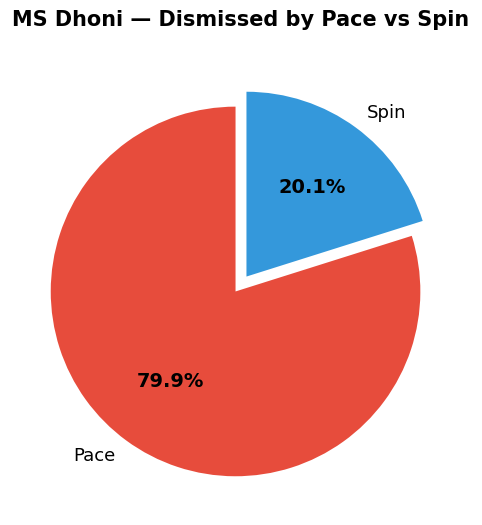

Chart saved!


In [15]:
import matplotlib.pyplot as plt

# Data
labels = ['Pace', 'Spin']
sizes = [bowler_type_counts['Pace'], bowler_type_counts['Spin']]
colors = ['#e74c3c', '#3498db']  # red for pace, blue for spin
explode = (0.05, 0.05)

# Create pie chart
plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 13}
)

# Make percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

plt.title(f'{player} — Dismissed by Pace vs Spin', 
          fontsize=15, fontweight='bold', pad=20)

plt.savefig('dhoni_pace_vs_spin.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [16]:
# Which overs does Dhoni get dismissed most
over_dismissals = dismissals_only['over'].value_counts().sort_index()

print("Dismissals per over:")
print(over_dismissals)

Dismissals per over:
over
2      1
5      1
6      2
7      4
8      1
9      1
10     6
11     7
12     8
13     6
14     8
15    13
16    15
17    21
18    20
19    35
Name: count, dtype: int64


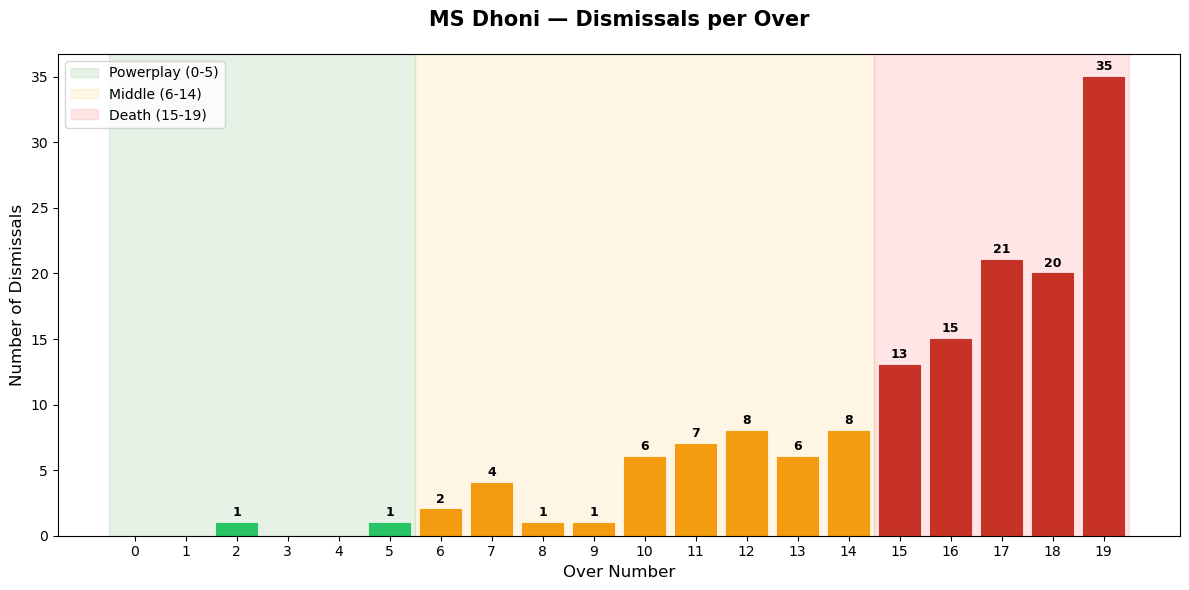

Chart saved!


In [17]:
plt.figure(figsize=(12, 6))

bars = plt.bar(over_dismissals.index, 
               over_dismissals.values,
               color='#e74c3c',
               edgecolor='white',
               linewidth=0.8)

# Highlight death overs
for i, bar in enumerate(bars):
    over_num = over_dismissals.index[i]
    if over_num >= 15:
        bar.set_color('#c0392b')  # darker red for death overs
    elif over_num <= 5:
        bar.set_color('#2ecc71')  # green for powerplay
    else:
        bar.set_color('#f39c12')  # orange for middle overs

# Add value on top of each bar
for bar, val in zip(bars, over_dismissals.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             str(val),
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

# Add phase labels
plt.axvspan(-0.5, 5.5, alpha=0.1, color='green', label='Powerplay (0-5)')
plt.axvspan(5.5, 14.5, alpha=0.1, color='orange', label='Middle (6-14)')
plt.axvspan(14.5, 19.5, alpha=0.1, color='red', label='Death (15-19)')

plt.title(f'{player} — Dismissals per Over', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Over Number', fontsize=12)
plt.ylabel('Number of Dismissals', fontsize=12)
plt.xticks(range(0, 20))
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dhoni_over_dismissals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [18]:
# How often Dhoni scores each run value
runs_distribution = player_data['batsman_runs'].value_counts().sort_index()

print("Dhoni's runs per ball distribution:")
print(runs_distribution)

Dhoni's runs per ball distribution:
batsman_runs
0    1423
1    1554
2     340
3      15
4     363
6     252
Name: count, dtype: int64


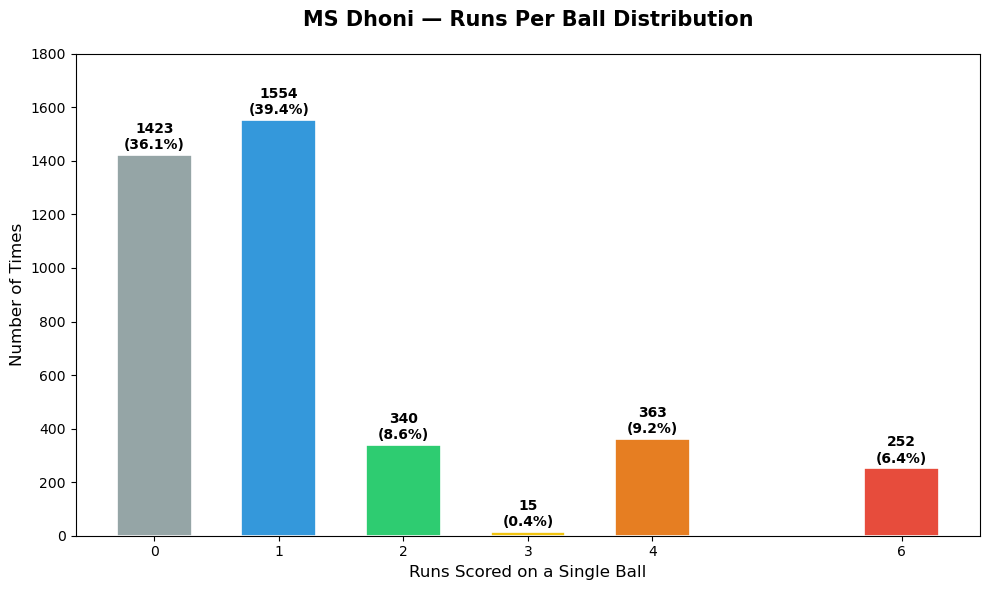

Chart saved!


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Run values and their counts
run_values = runs_distribution.index  # [0,1,2,3,4,6]
counts = runs_distribution.values     # [1423,1554,340,15,363,252]

# Different color for each bar
colors = ['#95a5a6','#3498db','#2ecc71','#f1c40f','#e67e22','#e74c3c']

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(run_values,   # x axis - run values
               counts,        # y axis - how many times
               color=colors,
               width=0.6,
               edgecolor='white',
               linewidth=1.2)

# Add count + percentage label on top of each bar
total_balls = len(player_data)  # total balls faced
for bar, val in zip(bars, counts):
    pct = (val / total_balls * 100).round(1)  # calculate percentage
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             f'{val}\n({pct}%)',   # show count and % both
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and styling
plt.title(f'{player} — Runs Per Ball Distribution',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Runs Scored on a Single Ball', fontsize=12)
plt.ylabel('Number of Times', fontsize=12)
plt.xticks(run_values)   # show only actual run values on x axis
plt.ylim(0, 1800)        # y axis limit
plt.tight_layout()
plt.savefig('dhoni_runs_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [20]:
import seaborn as sns
import numpy as np

# Create pivot table - overs vs runs scored
# This counts how many times Dhoni scored X runs in over Y
heatmap_data = player_data.pivot_table(
    values='ball',        # counting balls
    index='over',         # rows = over numbers
    columns='batsman_runs', # columns = runs scored
    aggfunc='count',      # count occurrences
    fill_value=0          # fill missing with 0
)

print("Heatmap data shape:", heatmap_data.shape)
print(heatmap_data.head(19))

Heatmap data shape: (19, 6)
batsman_runs    0    1   2  3   4   6
over                                 
1               1    0   0  0   0   0
2               5    0   0  0   0   0
3               5    1   0  0   2   0
4              21    5   1  0   3   0
5              19    9   1  0   5   0
6              43   21   4  0   2   2
7              31   32   2  2   7   1
8              55   42   5  0  11   1
9              92   69  11  2  10   4
10             97   98  16  0  12   7
11            101  117  17  2  11   6
12            104  140  25  1  13   7
13            109  149  13  1  19   9
14            145  165  31  1  27  19
15            130  184  35  2  30  21
16            121  178  45  0  47  26
17            118  157  37  1  49  39
18            120  119  48  1  58  41
19            106   68  49  2  57  69


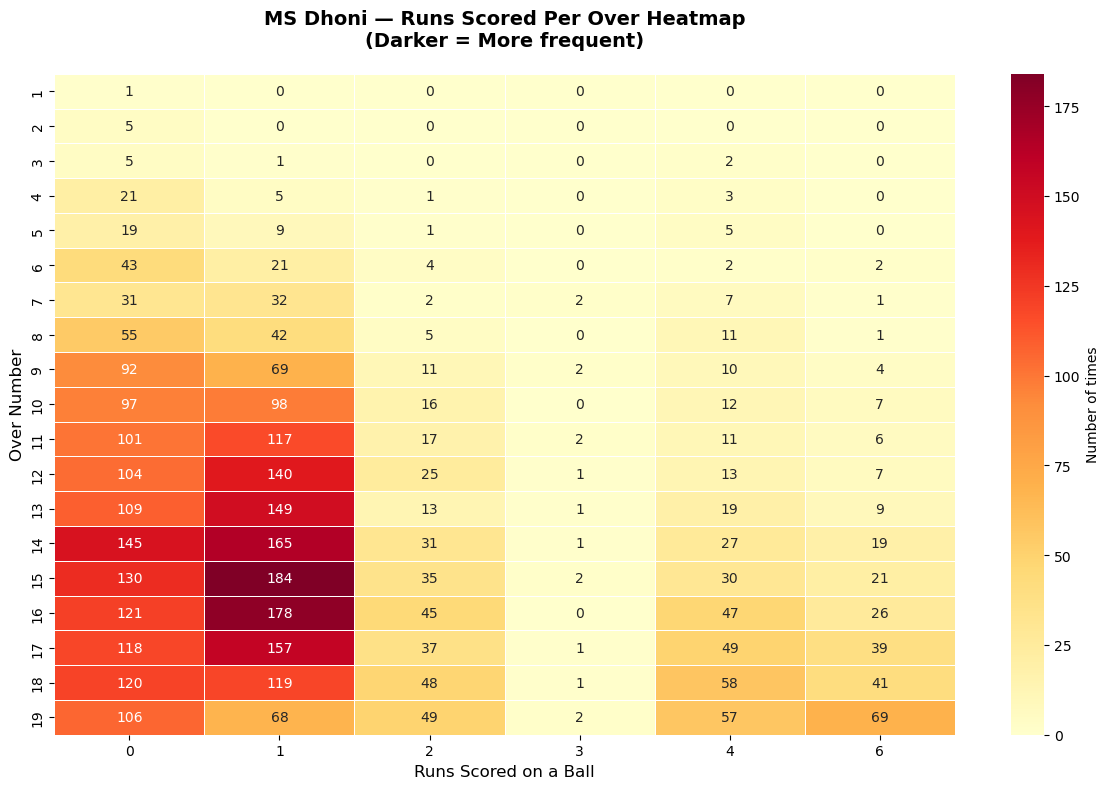

Heatmap saved!


In [21]:
# Create heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,              # our pivot table data
    cmap='YlOrRd',             # color: yellow=low, red=high
    annot=True,                # show numbers inside each cell
    fmt='d',                   # format numbers as integers
    linewidths=0.5,            # grid lines between cells
    linecolor='white',         # grid line color
    cbar_kws={'label': 'Number of times'}  # color bar label
)

# Labels and title
plt.title(f'{player} — Runs Scored Per Over Heatmap\n(Darker = More frequent)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Runs Scored on a Ball', fontsize=12)
plt.ylabel('Over Number', fontsize=12)
plt.tight_layout()
plt.savefig('dhoni_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

In [22]:
# ============================================
# SEASON-WISE PERFORMANCE ANALYSIS
# ============================================

# Step 1: Merge deliveries with matches to get season info
# We need 'season' column from matches and ball data from deliveries
merged_data = deliveries.merge(
    matches[['id', 'season']],  # take only id and season from matches
    left_on='match_id',          # deliveries has 'match_id'
    right_on='id',               # matches has 'id'
    how='left'                   # keep all rows from deliveries
)

# Step 2: Filter only Dhoni's balls from merged data
player_merged = merged_data[merged_data['batter'] == player]

# Step 3: Calculate stats per season
season_stats = player_merged.groupby('season').agg(
    balls=('batsman_runs', 'count'),       # total balls per season
    runs=('batsman_runs', 'sum'),          # total runs per season
    dismissals=('is_wicket', 'sum')        # total dismissals per season
).reset_index()

# Step 4: Add strike rate per season
season_stats['strike_rate'] = (
    season_stats['runs'] / season_stats['balls'] * 100
).round(2)

print(season_stats)

     season  balls  runs  dismissals  strike_rate
0   2007/08    319   414          11       129.78
1      2009    270   332           8       122.96
2   2009/10    215   287           9       133.49
3      2011    247   392          11       158.70
4      2012    283   358          11       126.50
5      2013    298   461          12       154.70
6      2014    258   371           6       143.80
7      2015    309   372          16       120.39
8      2016    220   284           8       129.09
9      2017    261   290          13       111.11
10     2018    321   455           7       141.74
11     2019    317   416           6       131.23
12  2020/21    175   200           8       114.29
13     2021    111   114           8       102.70
14     2022    198   232           8       117.17
15     2023     63   104           4       165.08
16     2024     82   161           3       196.34


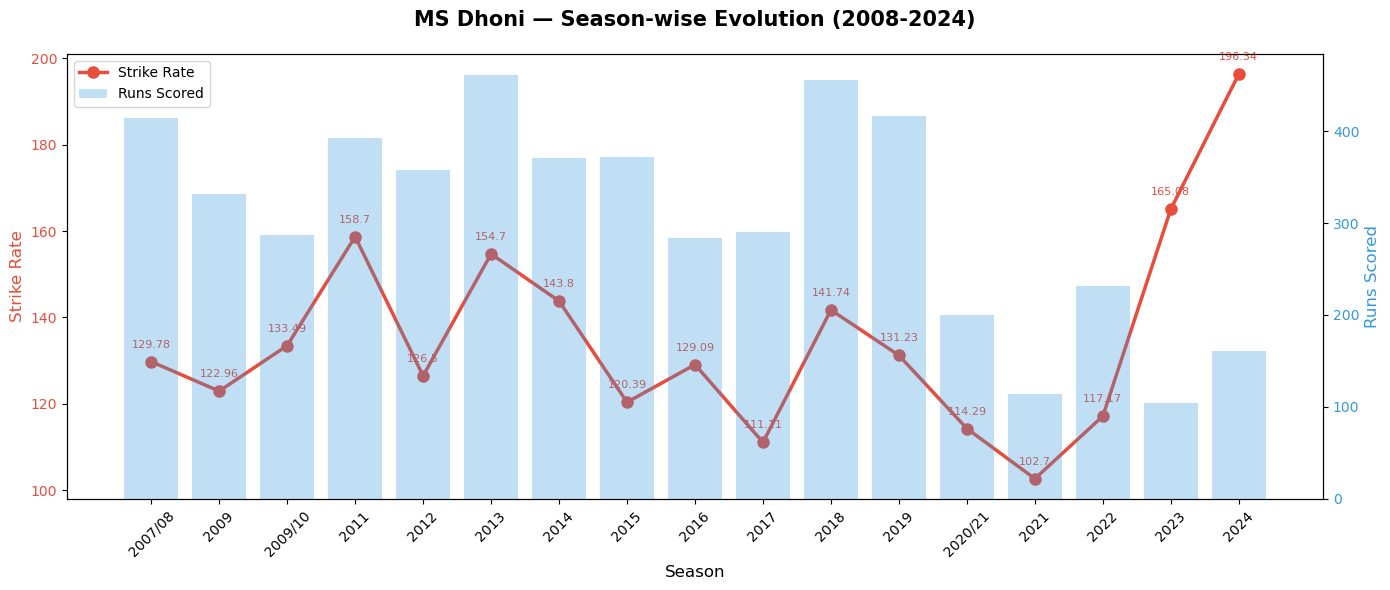

Chart saved!


In [23]:
# ============================================
# SEASON-WISE STRIKE RATE CHART
# ============================================

fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Plot 1: Strike Rate line (left y-axis) ---
color_sr = '#e74c3c'
ax1.plot(
    season_stats['season'],          # x axis - seasons
    season_stats['strike_rate'],     # y axis - strike rate
    color=color_sr,
    marker='o',                      # circle marker at each point
    linewidth=2.5,
    markersize=8,
    label='Strike Rate'
)

# Add SR value labels on each point
for i, row in season_stats.iterrows():
    ax1.annotate(
        f"{row['strike_rate']}",     # text to show
        (row['season'], row['strike_rate']),  # position
        textcoords="offset points",  # offset from point
        xytext=(0, 10),              # 10 points above
        ha='center',
        fontsize=8,
        color=color_sr
    )

ax1.set_xlabel('Season', fontsize=12)
ax1.set_ylabel('Strike Rate', color=color_sr, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_sr)
ax1.tick_params(axis='x', rotation=45)  # rotate x labels

# --- Plot 2: Runs bars (right y-axis) ---
ax2 = ax1.twinx()  # create second y-axis sharing same x-axis
color_runs = '#3498db'
ax2.bar(
    season_stats['season'],          # x axis - seasons
    season_stats['runs'],            # y axis - runs
    alpha=0.3,                       # transparent bars
    color=color_runs,
    label='Runs Scored'
)
ax2.set_ylabel('Runs Scored', color=color_runs, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_runs)

# --- Title and legend ---
plt.title(f'{player} — Season-wise Evolution (2008-2024)',
          fontsize=15, fontweight='bold', pad=20)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('dhoni_season_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [25]:
# ============================================
# VENUE ANALYSIS — Fixed merge with venue
# ============================================

# Step 1: Re-merge with venue column included this time
player_venue = deliveries[deliveries['batter'] == player].merge(
    matches[['id', 'season', 'venue']],  # added 'venue' here!
    left_on='match_id',
    right_on='id',
    how='left'
)

# Step 2: Calculate stats per venue
venue_stats = player_venue.groupby('venue').agg(
    balls=('batsman_runs', 'count'),
    runs=('batsman_runs', 'sum'),
    dismissals=('is_wicket', 'sum')
).reset_index()

# Step 3: Add strike rate
venue_stats['strike_rate'] = (
    venue_stats['runs'] / venue_stats['balls'] * 100
).round(2)

# Step 4: Only keep venues with 30+ balls faced
venue_stats = venue_stats[venue_stats['balls'] >= 30]

# Step 5: Sort by strike rate highest to lowest
venue_stats = venue_stats.sort_values('strike_rate', ascending=False)

print(f"Total venues analyzed: {len(venue_stats)}")
print("\nTop 5 best venues:")
print(venue_stats.head())
print("\nTop 5 worst venues:")
print(venue_stats.tail())

Total venues analyzed: 31

Top 5 best venues:
                                         venue  balls  runs  dismissals  \
33  Punjab Cricket Association Stadium, Mohali     39    70           2   
21                       M.Chinnaswamy Stadium     87   154           2   
7           Dr DY Patil Sports Academy, Mumbai     30    52           1   
19                       M Chinnaswamy Stadium    179   309           5   
24    MA Chidambaram Stadium, Chepauk, Chennai     65   106           4   

    strike_rate  
33       179.49  
21       177.01  
7        173.33  
19       172.63  
24       163.08  

Top 5 worst venues:
                           venue  balls  runs  dismissals  strike_rate
4      Brabourne Stadium, Mumbai     64    65           2       101.56
29         New Wanderers Stadium     38    34           2        89.47
18                     Kingsmead     53    47           4        88.68
37  Sardar Patel Stadium, Motera     59    52           1        88.14
0           Arun Ja

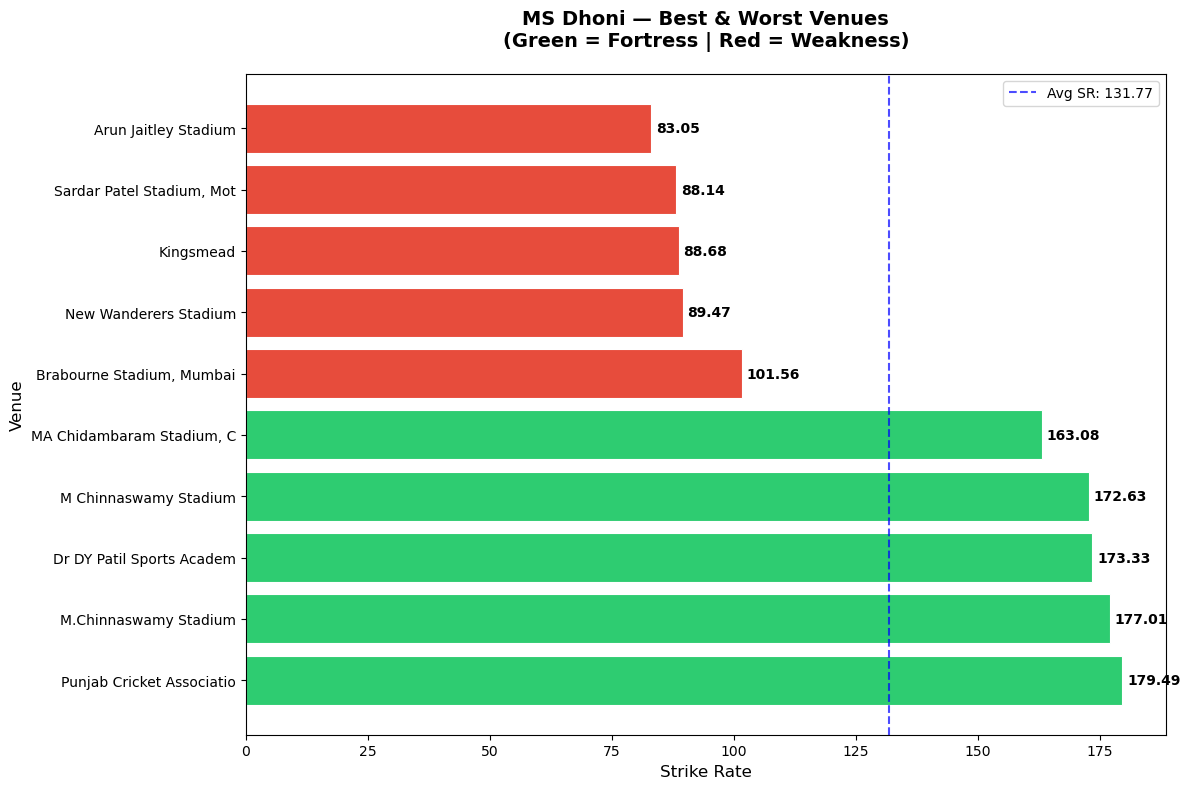

Chart saved!


In [26]:
# ============================================
# VENUE ANALYSIS CHART — Top 5 & Bottom 5
# ============================================

# Get top 5 and bottom 5 venues
top5 = venue_stats.head(5)      # best venues
bottom5 = venue_stats.tail(5)   # worst venues

# Combine both for chart
combined = pd.concat([top5, bottom5])

# Shorten long venue names for better display
combined = combined.copy()
combined['venue_short'] = combined['venue'].str[:25]  # first 25 chars only

# Colors — green for top 5, red for bottom 5
colors = ['#2ecc71'] * 5 + ['#e74c3c'] * 5

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(
    combined['venue_short'],     # y axis - venue names
    combined['strike_rate'],     # x axis - strike rate
    color=colors,
    edgecolor='white',
    linewidth=0.8
)

# Add SR value at end of each bar
for bar, val in zip(bars, combined['strike_rate']):
    plt.text(
        bar.get_width() + 1,         # x position
        bar.get_y() + bar.get_height()/2,  # y position
        f'{val}',                    # text
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Add reference line at average SR
avg_sr = venue_stats['strike_rate'].mean().round(2)
plt.axvline(x=avg_sr, color='blue',
            linestyle='--', alpha=0.7,
            label=f'Avg SR: {avg_sr}')

# Labels and styling
plt.title(f'{player} — Best & Worst Venues\n(Green = Fortress | Red = Weakness)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Strike Rate', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dhoni_venue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [27]:
# ============================================
# PRESSURE SITUATION ANALYSIS
# ============================================

# Step 1: Merge player data with match info
player_pressure = deliveries.merge(
    matches[['id', 'season', 'venue']],
    left_on='match_id',
    right_on='id',
    how='left'
)

# Step 2: Filter only death overs (17, 18, 19)
death_overs = player_pressure[
    (player_pressure['batter'] == player) &  # only Dhoni
    (player_pressure['over'] >= 17)           # only last 3 overs
]

# Step 3: Calculate runs scored per match in death overs
death_per_match = death_overs.groupby('match_id').agg(
    balls=('batsman_runs', 'count'),     # balls in death overs
    runs=('batsman_runs', 'sum'),        # runs in death overs
    sixes=('batsman_runs', lambda x: (x == 6).sum()),   # count sixes
    fours=('batsman_runs', lambda x: (x == 4).sum())    # count fours
).reset_index()

# Step 4: Filter only matches where he faced 6+ balls in death overs
death_per_match = death_per_match[death_per_match['balls'] >= 6]

# Step 5: Add strike rate
death_per_match['strike_rate'] = (
    death_per_match['runs'] / death_per_match['balls'] * 100
).round(2)

print(f"Matches where Dhoni batted in death overs: {len(death_per_match)}")
print(f"\nAverage death overs SR: {death_per_match['strike_rate'].mean().round(2)}")
print(f"Average runs in death overs per match: {death_per_match['runs'].mean().round(2)}")
print(f"Total sixes in death overs: {death_per_match['sixes'].sum()}")
print(f"Total fours in death overs: {death_per_match['fours'].sum()}")

Matches where Dhoni batted in death overs: 98

Average death overs SR: 196.97
Average runs in death overs per match: 20.02
Total sixes in death overs: 136
Total fours in death overs: 151


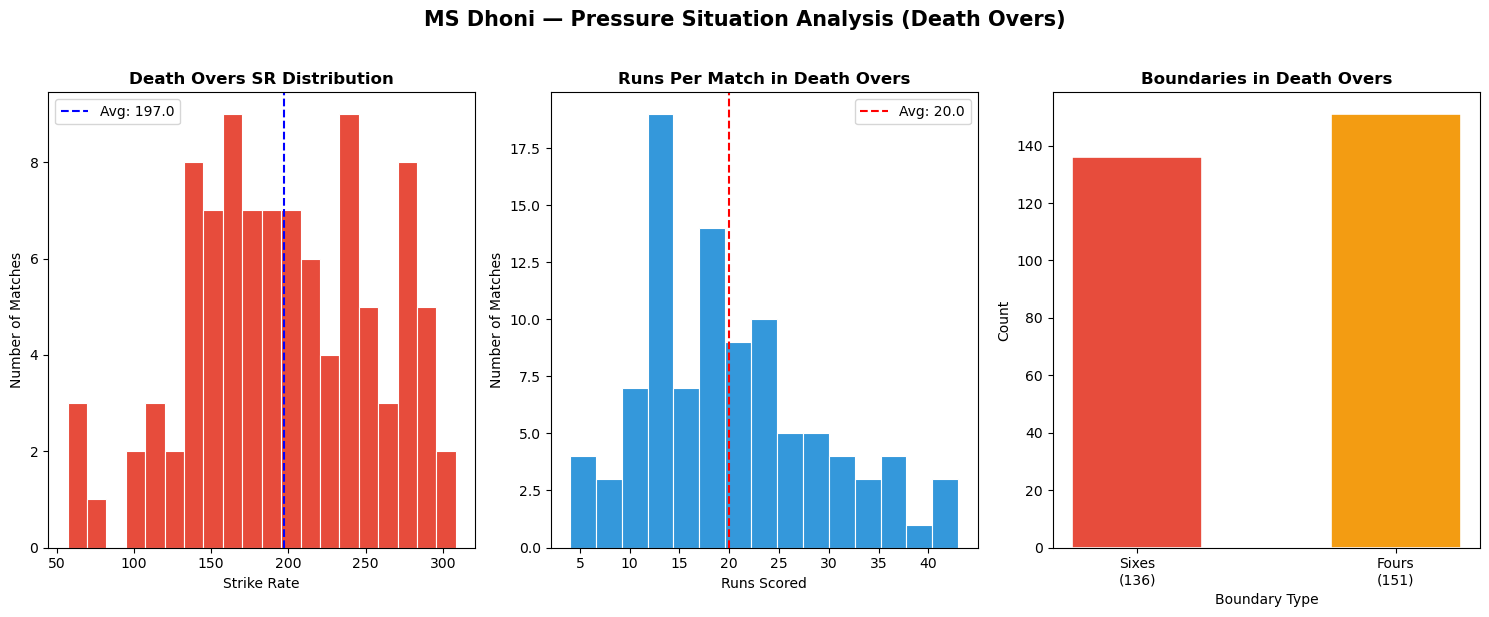

Chart saved!


In [28]:
# ============================================
# PRESSURE SITUATION VISUALIZATION
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 6))  # 3 charts side by side

# --- Chart 1: SR Distribution in death overs ---
axes[0].hist(
    death_per_match['strike_rate'],   # data
    bins=20,                           # number of bars
    color='#e74c3c',
    edgecolor='white',
    linewidth=0.8
)
axes[0].axvline(
    x=death_per_match['strike_rate'].mean(),  # average line
    color='blue', linestyle='--',
    label=f"Avg: {death_per_match['strike_rate'].mean().round(1)}"
)
axes[0].set_title('Death Overs SR Distribution', fontweight='bold')
axes[0].set_xlabel('Strike Rate')
axes[0].set_ylabel('Number of Matches')
axes[0].legend()

# --- Chart 2: Runs per match distribution ---
axes[1].hist(
    death_per_match['runs'],           # data
    bins=15,                           # number of bars
    color='#3498db',
    edgecolor='white',
    linewidth=0.8
)
axes[1].axvline(
    x=death_per_match['runs'].mean(),  # average line
    color='red', linestyle='--',
    label=f"Avg: {death_per_match['runs'].mean().round(1)}"
)
axes[1].set_title('Runs Per Match in Death Overs', fontweight='bold')
axes[1].set_xlabel('Runs Scored')
axes[1].set_ylabel('Number of Matches')
axes[1].legend()

# --- Chart 3: Sixes vs Fours comparison ---
boundary_data = [death_per_match['sixes'].sum(),
                 death_per_match['fours'].sum()]
boundary_labels = [f"Sixes\n({death_per_match['sixes'].sum()})",
                   f"Fours\n({death_per_match['fours'].sum()})"]
axes[2].bar(
    boundary_labels,                   # x axis
    boundary_data,                     # y axis
    color=['#e74c3c', '#f39c12'],
    edgecolor='white',
    linewidth=1.2,
    width=0.5
)
axes[2].set_title('Boundaries in Death Overs', fontweight='bold')
axes[2].set_xlabel('Boundary Type')
axes[2].set_ylabel('Count')

# Overall title
fig.suptitle(f'{player} — Pressure Situation Analysis (Death Overs)',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('dhoni_pressure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")